# Urban Biotope Semantic Segmentation with SegFormer

This notebook trains a **semantic segmentation model** to classify **multi class** (in Zürich) using high-resolution aerial imagery (SWISSIMAGE 10 cm).

The workflow:

1. Load dataset from Google Drive
2. Prepare PyTorch dataset
3. Apply preprocessing and augmentations
4. Fine-tune a SegFormer model
5. Evaluate performance
6. Visualize predictions

We use a **transformer-based segmentation model (SegFormer)** from Hugging Face.


In [1]:
!pip install -q transformers datasets evaluate accelerate
!pip install -q rasterio albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_ROOT = "/content/drive/MyDrive/data_new"

In [4]:
import torch

print("GPU:", torch.cuda.is_available())

GPU: True


In [5]:
import os
import numpy as np
import torch
import rasterio
from PIL import Image

from torch.utils.data import Dataset, DataLoader

from transformers import (
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
    TrainingArguments,
    Trainer
)

import albumentations as A

In [6]:
import os
import torch
import numpy as np
import rasterio
from torch.utils.data import Dataset
from PIL import Image # Import PIL for JPG/PNG

class BiotopeDataset(Dataset):
    def __init__(self, root_dir, split, processor, task_name="masks_combined", transform=None):
        """
        Args:
            root_dir: Base path (e.g., '../01_data/processed_modular')
            split: 'train' or 'val'
            processor: The SegFormerImageProcessor
            task_name: The subfolder for masks (e.g., 'masks_builtup', 'masks_grassland')
            transform: Albumentations augmentations
        """
        self.img_dir = os.path.join(root_dir, split, "images")
        self.mask_dir = os.path.join(root_dir, split, task_name)

        all_image_files = sorted([f for f in os.listdir(self.img_dir) if f.endswith('.jpg')])
        self.images = []
        skipped_count = 0

        for img_name in all_image_files:
            mask_name = img_name.replace("_swissimage.jpg", "_mask.png")
            mask_path = os.path.join(self.mask_dir, mask_name)

            img_path = os.path.join(self.img_dir, img_name)

            if os.path.exists(mask_path) and os.path.exists(img_path):
                self.images.append(img_name)
            else:
                skipped_count += 1
                # Optional: print specific missing files if needed
                # print(f"Warning: Skipping {img_name} due to missing image or mask.")

        if skipped_count > 0:
            print(f"Info: Skipped {skipped_count} samples in '{split}' split due to missing image or mask files.")
        print(f"Info: '{split}' split loaded with {len(self.images)} valid samples.")

        self.processor = processor
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 1. Setup paths
        img_name = self.images[idx]
        mask_name = img_name.replace("_swissimage.jpg", "_mask.png")

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # 2. Load Image (RGB) using PIL for JPG
        image = Image.open(img_path).convert("RGB")
        image = np.array(image) # Convert to numpy array (H, W, C)

        # 3. Load Mask using PIL for PNG (expecting single channel grayscale)
        mask = Image.open(mask_path).convert("L") # Convert to grayscale
        mask = np.array(mask) # Convert to numpy array (H, W)
        # Ensure mask is integer type (0 or 1, or other class IDs)
        mask = mask.astype(np.int64)

        # 4. Apply Augmentations (Albumentations)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # 5. SegFormer Processing
        # We pass the mask as 'segmentation_maps' so the processor handles
        # resizing if your image size ever changes from 512.
        encoded = self.processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt"
        )

        # Remove batch dimension added by processor [1, C, H, W] -> [C, H, W]
        encoded = {k: v.squeeze(0) for k, v in encoded.items()}

        return encoded

In [26]:
import os
import json

inference_config = {
    "version_tag": "inference_whole_testse", # Unique identifier for this inference run
    "test_subset_ratio": 1, # Ratio of the test dataset to use (0.0 to 1.0)
    "test_batch_size": 4, # Batch size for inference
    "target_input_resolution": 256, # Use the same resolution as training (hardcoded 256 for inference)
    "initial_crop_size": 512, # Use the same initial crop size as training (hardcoded 512 for inference)
    "use_fp16": True, # Whether to use mixed precision for inference
    "random_seed": 42, # Random seed for reproducibility
    "test_split_name": "test" # Name of the test split folder (e.g., 'test')
}

# Define the paths to your pre-trained models
# Each key should correspond to a class or a model trained for a specific focus.
# The value should be the full path to the saved model checkpoint (e.g., best_model.pth)
model_paths = {
    "Built-Up": "/content/drive/MyDrive/segformer_builtup/built_up_newdata_b3_01/best_model.pth",
    "Grassland": "/content/drive/MyDrive/segformer_grassland/grassland_newdata_b3_01/best_model.pth",
    "Bushes & Trees": "/content/drive/MyDrive/segformer_highveg/highveg_newdata_b3_01/best_model.pth",
    # Add the path for the new multi-class model
    "Multiclass": "/content/drive/MyDrive/segformer_multiclass/multiclass_newdata_b3_01/best_model.pth"
}

# Base directory for all inference outputs
OUTPUT_INFERENCE_ROOT_DIR = "/content/drive/MyDrive/segformer_multiclass_inference_results"

# Create a specific output directory for this inference run
OUTPUT_INFERENCE_DIR = os.path.join(OUTPUT_INFERENCE_ROOT_DIR, inference_config["version_tag"])
os.makedirs(OUTPUT_INFERENCE_DIR, exist_ok=True)
print(f"Inference outputs will be saved to: {OUTPUT_INFERENCE_DIR}")

# Save the inference configuration to the output directory
with open(os.path.join(OUTPUT_INFERENCE_DIR, "inference_config.json"), "w") as f:
    json.dump(inference_config, f, indent=4)

print("Inference configuration loaded and saved.")

Inference outputs will be saved to: /content/drive/MyDrive/segformer_multiclass_inference_results/inference_whole_testse
Inference configuration loaded and saved.


In [8]:
import numpy as np
import torch
from torch.utils.data import DataLoader

def get_intersection_union_per_class(preds, labels, num_classes):
    """
    Calculates per-class intersection and union.
    Args:
        preds (np.array): Predicted masks.
        labels (np.array): Ground truth masks.
        num_classes (int): Total number of classes.
    Returns:
        tuple: (intersection_per_class, union_per_class)
    """
    # Flatten predictions and labels, ignoring the 255 (ignore_index) pixels
    preds = preds.flatten()
    labels = labels.flatten()

    valid_pixels = labels != 255
    preds = preds[valid_pixels]
    labels = labels[valid_pixels]

    # Initialize per-class intersection and union
    intersection = np.zeros(num_classes)
    union = np.zeros(num_classes)

    for cls in range(num_classes):
        pred_mask = (preds == cls)
        label_mask = (labels == cls)

        intersection[cls] = (pred_mask & label_mask).sum()
        union[cls] = (pred_mask | label_mask).sum()

    return intersection, union

In [9]:
from transformers import SegformerImageProcessor, SegformerConfig

# Initialize the processor with parameters from inference_config
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b3-finetuned-ade-512-512",
    size={'height': inference_config["target_input_resolution"], 'width': inference_config["target_input_resolution"]},
    do_resize=True # Ensure resizing is performed to the new target size
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


In [27]:
from torch.utils.data import Subset
import albumentations as A

# Define a simple transform for the test set (just resizing/cropping as per config)
# No aggressive augmentations needed for inference
test_transform = A.Compose([
    A.CenterCrop(inference_config["initial_crop_size"], inference_config["initial_crop_size"]),
    A.Resize(inference_config["target_input_resolution"], inference_config["target_input_resolution"])
])

# Load the test dataset
test_dataset = BiotopeDataset(
    DATA_ROOT,
    inference_config["test_split_name"],
    processor,
    transform=test_transform,
    task_name="masks_combined",
)

# Apply subsetting if specified in the inference config
if inference_config["test_subset_ratio"] < 1.0:
    test_size = int(len(test_dataset) * inference_config["test_subset_ratio"])
    test_indices = np.random.choice(len(test_dataset), test_size, replace=False)
    test_dataset = Subset(test_dataset, test_indices)

print(f"Test dataset loaded with {len(test_dataset)} samples (subset ratio: {inference_config['test_subset_ratio']}).")

# Create DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=inference_config["test_batch_size"],
    shuffle=False,
    num_workers=2
)

Info: 'test' split loaded with 1448 valid samples.
Test dataset loaded with 1448 samples (subset ratio: 1).


In [28]:
id2label = {
0: "Other",
1: "Built-Up",
2: "Grassland",
3: "Bushes & Trees"
}

label2id = {v:k for k,v in id2label.items()}
num_classes = len(id2label)

In [29]:
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DataFrame to store mIoU results for all models
miou_results_df = pd.DataFrame(columns=['sample_id'])

# Get a list of sample_ids from the test_dataset
# This assumes the BiotopeDataset stores file names or unique IDs
# If using Subset, we need to map back to original dataset indices to get the names
sample_ids = []
if isinstance(test_dataset, Subset):
    original_dataset = test_dataset.dataset
    for idx in test_dataset.indices:
        img_name = original_dataset.images[idx]
        sample_ids.append(img_name.replace("_swissimage.jpg", ""))
else:
    for img_name in test_dataset.images:
        sample_ids.append(img_name.replace("_swissimage.jpg", ""))

miou_results_df['sample_id'] = sample_ids

all_model_predictions = {}

# Loop through each model specified in model_paths
for model_name, model_path in model_paths.items():
    print(f"\n--- Running inference for model: {model_name} ---")

    # Define the base model identifier for loading the architecture (SegFormer-B3 in this case)
    base_pretrained_model_name = "nvidia/segformer-b3-finetuned-ade-512-512"

    # Load the base configuration from the original pretrained model to get the correct architecture (e.g., B3)
    base_config_for_architecture = SegformerConfig.from_pretrained(base_pretrained_model_name)

    # --- Conditional model setup based on model_name ---
    if model_name == "Multiclass":
        # For the multi-class model, use the global id2label and num_classes
        temp_model_config = SegformerConfig.from_dict(base_config_for_architecture.to_dict())
        temp_model_config.num_labels = num_classes # Use global num_classes
        temp_model_config.id2label = id2label # Use global id2label
        temp_model_config.label2id = label2id # Use global label2id
        temp_model_config.image_size = inference_config["target_input_resolution"]

        # Initialize the SegFormer model
        model_inference = SegformerForSemanticSegmentation.from_pretrained(
            base_pretrained_model_name,
            config=temp_model_config,
            ignore_mismatched_sizes=True # Allow mismatches in classification head
        )
        # Set number of classes for mIoU calculation
        miou_num_classes_for_current_model = num_classes
    else:
        # For binary models, use the existing logic
        target_global_class_id = label2id[model_name] # Get global ID for binary target
        binary_id2label = {0: "Not " + model_name, 1: model_name}
        binary_label2id = {v:k for k,v in binary_id2label.items()}

        temp_model_config = SegformerConfig.from_dict(base_config_for_architecture.to_dict())
        temp_model_config.num_labels = 2 # Set to 2 for binary classification
        temp_model_config.id2label = binary_id2label
        temp_model_config.label2id = binary_label2id
        temp_model_config.image_size = inference_config["target_input_resolution"]

        model_inference = SegformerForSemanticSegmentation.from_pretrained(
            base_pretrained_model_name,
            config=temp_model_config,
            ignore_mismatched_sizes=True
        )
        # Set number of classes for mIoU calculation
        miou_num_classes_for_current_model = 2

    # Load the state_dict from the fine-tuned checkpoint.
    model_inference.load_state_dict(torch.load(model_path, map_location=device), strict=False)
    model_inference.to(device)
    model_inference.eval()

    # Create a directory for this model's predictions
    model_output_dir = os.path.join(OUTPUT_INFERENCE_DIR, f"predictions_{model_name.replace(' ', '_')}")
    os.makedirs(model_output_dir, exist_ok=True)

    per_sample_mious = []
    model_predictions_for_visualization = [] # Store predictions for visualization later

    with torch.no_grad():
        for i, batch in enumerate(tqdm(test_loader, desc=f"Inferring {model_name}")):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device) # These are always multi-class ground truths from the dataset

            with torch.cuda.amp.autocast(enabled=inference_config["use_fp16"]):
                outputs = model_inference(pixel_values=pixel_values)

            logits = outputs.logits

            # Upsample logits to original label size
            target_h, target_w = labels.shape[-2:]
            logits = F.interpolate(
                logits,
                size=(target_h, target_w),
                mode="bilinear",
                align_corners=False
            )

            preds = logits.argmax(dim=1).cpu().numpy() # Predictions from the current model

            labels_np = labels.cpu().numpy() # Original multi-class labels

            # Calculate mIoU for each sample in the batch
            for j in range(preds.shape[0]):
                current_sample_pred = preds[j]
                current_sample_label_multiclass = labels_np[j]

                # Save prediction mask as PNG
                original_sample_idx = i * test_loader.batch_size + j
                if isinstance(test_dataset, Subset):
                    original_file_name = test_dataset.dataset.images[test_dataset.indices[original_sample_idx]]
                else:
                    original_file_name = test_dataset.images[original_sample_idx]

                base_name = original_file_name.replace("_swissimage.jpg", "")
                pred_mask_filename = os.path.join(model_output_dir, f"{base_name}_prediction.png")

                if model_name == "Multiclass":
                    # For multi-class model, save its direct predictions (0 to num_classes-1)
                    pred_img = Image.fromarray(current_sample_pred.astype(np.uint8))
                    pred_img.save(pred_mask_filename)

                    # mIoU calculation for multi-class model
                    intersections, unions = get_intersection_union_per_class(
                        current_sample_pred, current_sample_label_multiclass, num_classes=miou_num_classes_for_current_model
                    )
                else:
                    # For binary models, save binary predictions (0 or 1)
                    pred_img = Image.fromarray(current_sample_pred.astype(np.uint8))
                    pred_img.save(pred_mask_filename)

                    # Convert multi-class ground truth to binary for mIoU calculation for binary models
                    sample_label_binary = (current_sample_label_multiclass == target_global_class_id).astype(np.int64)
                    intersections, unions = get_intersection_union_per_class(
                        current_sample_pred, sample_label_binary, num_classes=miou_num_classes_for_current_model
                    )

                ious = [inter / un for inter, un in zip(intersections, unions) if un > 0] # Avoid division by zero
                sample_miou = np.mean(ious) if len(ious) > 0 else 0.0
                per_sample_mious.append(sample_miou)

                # Store for visualization.
                if len(model_predictions_for_visualization) < 5 : # Store first few samples for visualization per model
                    if model_name == "Multiclass":
                        model_predictions_for_visualization.append({
                            "image": batch["pixel_values"][j].cpu().numpy(),
                            "ground_truth": current_sample_label_multiclass, # Keep original multi-class GT for comparison
                            "prediction": current_sample_pred, # Store raw multi-class prediction
                            "model_type": "multiclass",
                            "sample_id": base_name
                        })
                    else:
                        model_predictions_for_visualization.append({
                            "image": batch["pixel_values"][j].cpu().numpy(),
                            "ground_truth": current_sample_label_multiclass, # Keep original multi-class GT for comparison
                            "prediction": current_sample_pred, # Store binary prediction (0 or 1)
                            "target_class_id": target_global_class_id, # Store which class this model targets
                            "model_type": "binary",
                            "sample_id": base_name
                        })


            del pixel_values, labels, outputs, logits, preds, labels_np
            torch.cuda.empty_cache()

    miou_results_df[f'mIoU_{model_name.replace(" ", "_")}'] = per_sample_mious
    print(f"Average mIoU for {model_name}: {np.mean(per_sample_mious):.4f}")

    # Store for visualization
    all_model_predictions[model_name] = model_predictions_for_visualization

# Save the mIoU results to CSV
miou_csv_path = os.path.join(OUTPUT_INFERENCE_DIR, "inference_miou_results.csv")
miou_results_df.to_csv(miou_csv_path, index=False)
print(f"All mIoU results saved to {miou_csv_path}")


--- Running inference for model: Built-Up ---


Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Inferring Built-Up:   0%|          | 0/362 [00:00<?, ?it/s]/tmp/ipykernel_972/3108319482.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda

Average mIoU for Built-Up: 0.7417

--- Running inference for model: Grassland ---


Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

...

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([2, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Inferring Bushes & Trees:   0%|          | 0/362 [00:00<?, ?it/s]/tmp/ipykernel_972/3108319482.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torc

Average mIoU for Bushes & Trees: 0.7355

--- Running inference for model: Multiclass ---


Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([4])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([4, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Inferring Multiclass:   0%|          | 0/362 [00:00<?, ?it/s]/tmp/ipykernel_972/3108319482.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cu

Average mIoU for Multiclass: 0.5384
All mIoU results saved to /content/drive/MyDrive/segformer_multiclass_inference_results/inference_whole_testse/inference_miou_results.csv



--- Visualizing a few inference samples ---


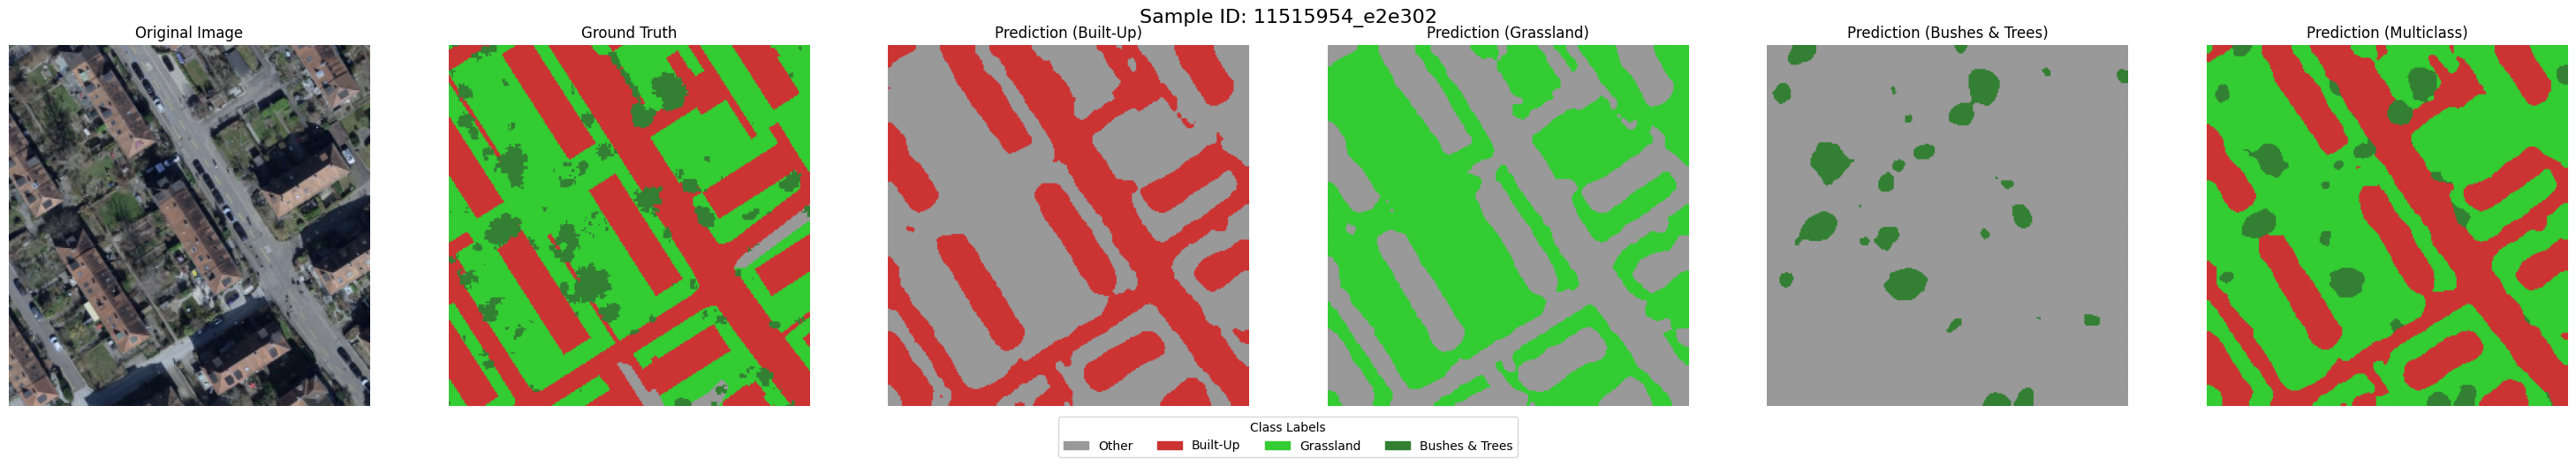

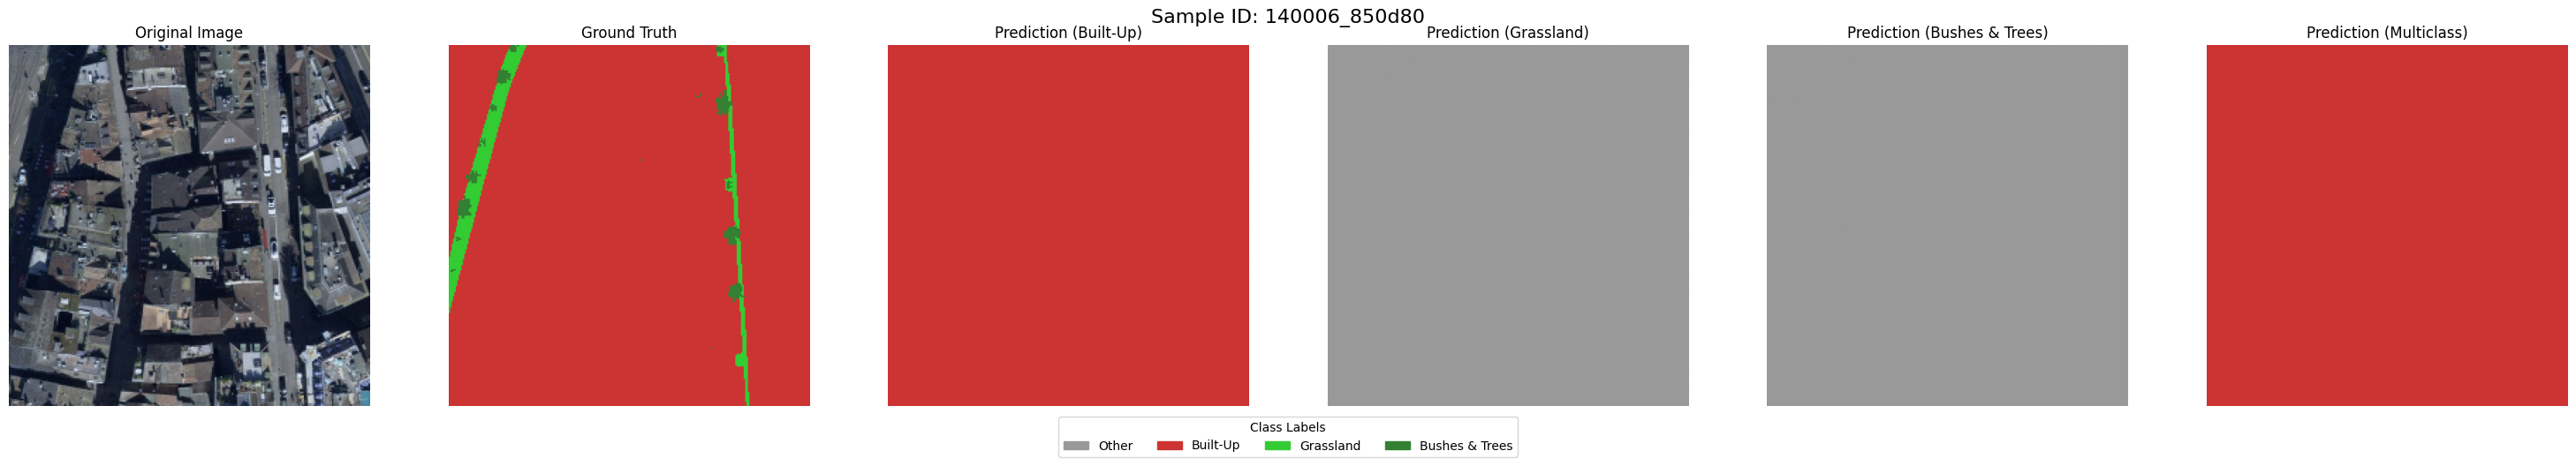

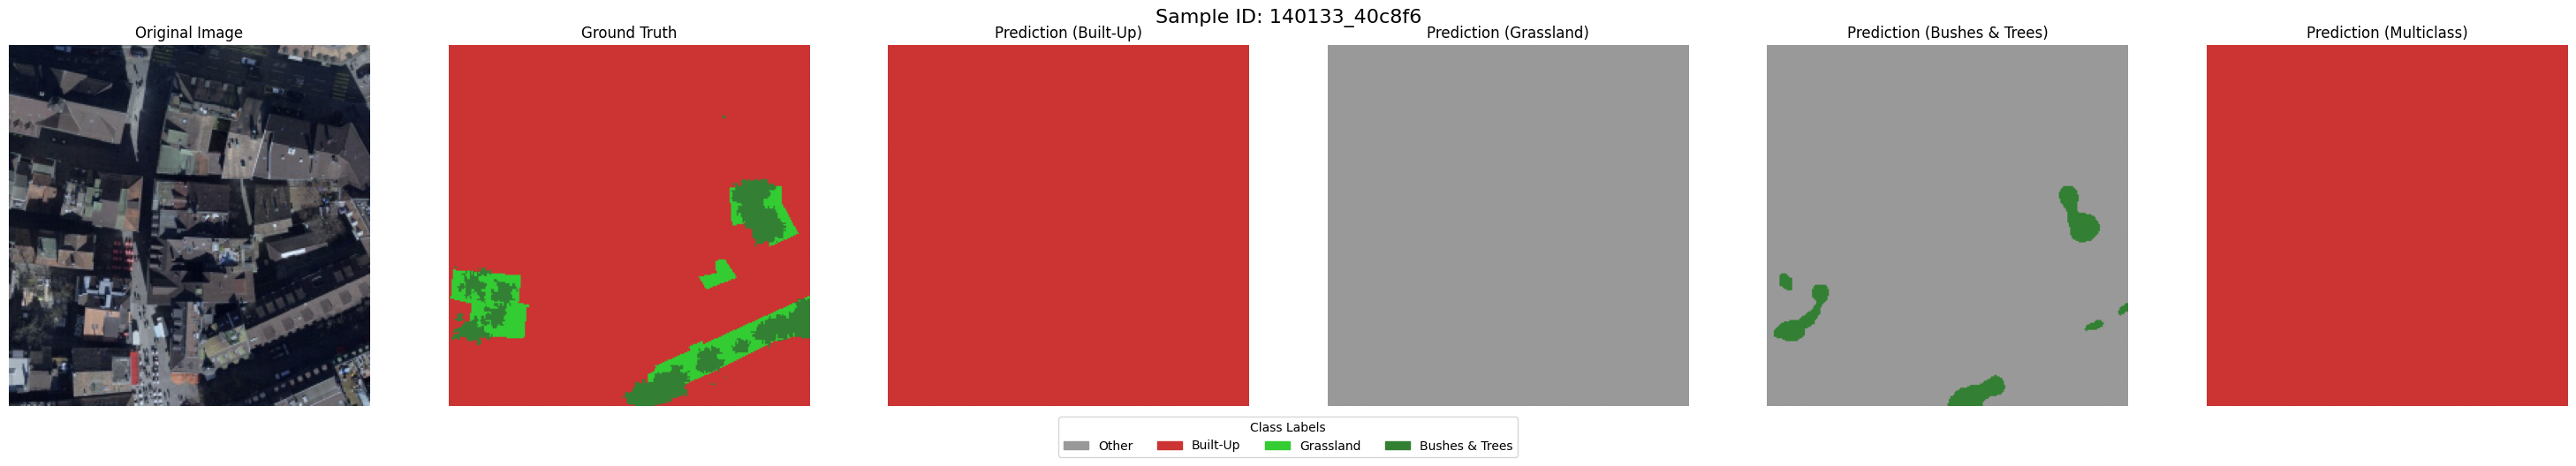

In [30]:
# ============================================================
# VISUALIZATION OF INFERENCE RESULTS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Define the color map based on id2label (assuming it's already defined from the training section)
colors = [
    (0.6, 0.6, 0.6),  # Other (index 0) - Grey
    (0.8, 0.2, 0.2),  # Built-Up (index 1) - Reddish
    (0.2, 0.8, 0.2),  # Grassland (index 2) - Greenish
    (0.2, 0.5, 0.2)   # Bushes & Trees (index 3) - Darker Green
]

cmap = ListedColormap(colors[:num_classes])

# Create legend patches using the global id2label
patches = []
for class_id, class_name in id2label.items():
    if class_id < len(colors):
        patch = mpatches.Patch(color=colors[class_id], label=class_name)
        patches.append(patch)

print("\n--- Visualizing a few inference samples ---")

# Determine how many samples to visualize
num_samples_to_visualize = 3

# Get the first model's predictions to use as a reference for original images and GT
# This assumes all_model_predictions is populated and has at least one model.
if not all_model_predictions:
    print("No model predictions available for visualization.")
else:
    # Use the first model in the dictionary to get the sample images and ground truths
    # This assumes that the samples stored for visualization are consistent across models
    first_model_name = list(all_model_predictions.keys())[0]
    reference_predictions = all_model_predictions[first_model_name]

    for sample_idx in range(min(num_samples_to_visualize, len(reference_predictions))):
        sample_data_ref = reference_predictions[sample_idx] # Reference for image and GT
        img = sample_data_ref["image"]
        gt_mask = sample_data_ref["ground_truth"] # This is the multi-class GT
        sample_id = sample_data_ref["sample_id"]

        # Normalize image for display
        img = np.transpose(img, (1, 2, 0))
        img = (img - img.min()) / (img.max() - img.min()) # Scale to 0-1

        fig, axes = plt.subplots(1, 2 + len(model_paths), figsize=(5 * (2 + len(model_paths)), 5))
        fig.suptitle(f"Sample ID: {sample_id}", fontsize=16)

        # Plot Original Image
        axes[0].imshow(img)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        # Plot Ground Truth (multi-class)
        axes[1].imshow(gt_mask, cmap=cmap, vmin=0, vmax=num_classes-1)
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        # Plot Predictions from each model
        for i, (model_name, predictions_list) in enumerate(all_model_predictions.items()):
            # Get the specific sample's prediction from the current model's list
            current_model_sample_data = predictions_list[sample_idx]
            raw_pred = current_model_sample_data["prediction"]
            model_type = current_model_sample_data["model_type"]

            if model_type == "binary":
                target_class_id_for_this_model = current_model_sample_data["target_class_id"]
                # Create a display mask for binary model:
                # Pixels predicted as 1 (target class) are mapped to their global ID
                # Pixels predicted as 0 (background) are mapped to global ID 0 ("Other")
                display_pred_mask = np.copy(raw_pred)
                display_pred_mask[raw_pred == 1] = target_class_id_for_this_model
                display_pred_mask[raw_pred == 0] = 0 # Map background to "Other" class ID
            else: # model_type == "multiclass"
                # Multi-class predictions can be used directly for display
                display_pred_mask = raw_pred

            axes[2 + i].imshow(display_pred_mask, cmap=cmap, vmin=0, vmax=num_classes-1)
            axes[2 + i].set_title(f"Prediction ({model_name})")
            axes[2 + i].axis("off")

        plt.figlegend(handles=patches, loc='lower center', ncol=len(id2label), bbox_to_anchor=(0.5, -0.05), title="Class Labels")
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()

### Focused Visualization: Multi-Class vs. Ensemble

### Ensemble Predictions (Rule-Based Hierarchy)

In [32]:
def compose_hierarchical_mask(built_arr, grass_arr, highveg_arr):
    """
    Combines three binary masks into one categorical mask based on priority.
    Hierarchy: Bushes & Trees (3) > Grassland (2) > Built-up (1)
    """
    # Initialize background (Class 0, 'Other')
    combined = np.zeros_like(built_arr, dtype=np.uint8)

    # 1. Apply Built-up (Class 1) - Lowest Priority
    combined[built_arr == 1] = 1

    # 2. Apply Grassland (Class 2) - Overwrites Built-up
    combined[grass_arr == 1] = 2

    # 3. Apply Bushes & Trees (Class 3) - Overwrites Everything
    combined[highveg_arr == 1] = 3

    return combined

print("Hierarchical mask composition function defined.")

Hierarchical mask composition function defined.


In [44]:
print("\n--- Generating Ensemble Predictions ---")

# Create a directory for ensemble predictions
ENSEMBLE_OUTPUT_DIR = os.path.join(OUTPUT_INFERENCE_DIR, "predictions_Ensemble_RuleBased")
os.makedirs(ENSEMBLE_OUTPUT_DIR, exist_ok=True)
print(f"Ensemble predictions will be saved to: {ENSEMBLE_OUTPUT_DIR}")

ensemble_mious = []
ensemble_predictions_for_visualization = []
ensemble_model_name = "Ensemble Rule-Based" # A clear name for the ensemble

# Paths to the individual binary model prediction directories
builtup_pred_dir = os.path.join(OUTPUT_INFERENCE_DIR, "predictions_Built-Up")
grassland_pred_dir = os.path.join(OUTPUT_INFERENCE_DIR, "predictions_Grassland")
highveg_pred_dir = os.path.join(OUTPUT_INFERENCE_DIR, "predictions_Bushes_&_Trees")

with torch.no_grad():
    # Loop through the test loader to access original images and ground truths
    for i, batch in enumerate(tqdm(test_loader, desc=f"Inferring {ensemble_model_name}")):
        labels = batch["labels"].cpu().numpy() # Multi-class ground truths for the batch

        for j in range(labels.shape[0]):
            original_sample_idx = i * test_loader.batch_size + j
            if isinstance(test_dataset, Subset):
                original_file_name = test_dataset.dataset.images[test_dataset.indices[original_sample_idx]]
            else:
                original_file_name = test_dataset.images[original_sample_idx]

            base_name = original_file_name.replace("_swissimage.jpg", "")

            # Load individual binary predictions from saved PNGs
            builtup_pred_path = os.path.join(builtup_pred_dir, f"{base_name}_prediction.png")
            grassland_pred_path = os.path.join(grassland_pred_dir, f"{base_name}_prediction.png")
            highveg_pred_path = os.path.join(highveg_pred_dir, f"{base_name}_prediction.png")

            # Ensure files exist before attempting to open
            if not (os.path.exists(builtup_pred_path) and os.path.exists(grassland_pred_path) and os.path.exists(highveg_pred_path)):
                print(f"Warning: Skipping {base_name} for ensemble due to missing binary predictions.")
                # Append NaN or 0.0 for mIoU if any prediction is missing
                ensemble_mious.append(np.nan)
                continue

            built_arr = np.array(Image.open(builtup_pred_path).convert("L"))
            grass_arr = np.array(Image.open(grassland_pred_path).convert("L"))
            highveg_arr = np.array(Image.open(highveg_pred_path).convert("L"))

            # Compose the hierarchical mask
            composed_mask = compose_hierarchical_mask(built_arr, grass_arr, highveg_arr)

            # Get the ground truth for the current sample
            current_sample_label_multiclass = labels[j]

            # Calculate mIoU for the composed mask
            intersections, unions = get_intersection_union_per_class(
                composed_mask, current_sample_label_multiclass, num_classes=num_classes
            )
            ious = [inter / un for inter, un in zip(intersections, unions) if un > 0] # Avoid division by zero
            sample_miou = np.mean(ious) if len(ious) > 0 else 0.0
            ensemble_mious.append(sample_miou)

            # Save the composed mask
            composed_mask_filename = os.path.join(ENSEMBLE_OUTPUT_DIR, f"{base_name}_composed_prediction.png")
            Image.fromarray(composed_mask.astype(np.uint8)).save(composed_mask_filename)

            # Store for visualization
            if len(ensemble_predictions_for_visualization) < 5:
                ensemble_predictions_for_visualization.append({
                    "image": batch["pixel_values"][j].cpu().numpy(),
                    "ground_truth": current_sample_label_multiclass,
                    "prediction": composed_mask,
                    "model_type": "multiclass", # Treat composed as multi-class for display
                    "sample_id": base_name
                })

print(f"Average mIoU for {ensemble_model_name}: {np.mean(ensemble_mious):.4f}")


--- Generating Ensemble Predictions ---
Ensemble predictions will be saved to: /content/drive/MyDrive/segformer_multiclass_inference_results/inference_whole_testse/predictions_Ensemble_RuleBased


Inferring Ensemble Rule-Based:   5%|▍         | 18/362 [00:01<00:28, 11.87it/s]


KeyboardInterrupt: 

In [34]:
# Add ensemble mIoU to the DataFrame and save
miou_results_df[f'mIoU_{ensemble_model_name.replace(" ", "_")}'] = ensemble_mious
miou_csv_path = os.path.join(OUTPUT_INFERENCE_DIR, "inference_miou_results.csv")
miou_results_df.to_csv(miou_csv_path, index=False)
print(f"Updated mIoU results saved to {miou_csv_path}")
display(miou_results_df.head())

Updated mIoU results saved to /content/drive/MyDrive/segformer_multiclass_inference_results/inference_whole_testse/inference_miou_results.csv


,sample_id,mIoU_Built-Up,mIoU_Grassland,mIoU_Bushes_&_Trees,mIoU_Multiclass,mIoU_Ensemble_Rule-Based
0,11515954_e2e302,0.854246,0.740193,0.659035,0.473038,0.508302
1,140006_850d80,0.476364,0.481483,0.494881,0.317576,0.317576
2,140133_40c8f6,0.446373,0.476021,0.691845,0.297582,0.445742
3,140158_fdafc5,0.462415,0.475546,0.777985,0.370692,0.382118
4,140186_7fbe08,0.446953,0.474236,0.665954,0.297969,0.427678



--- Visualizing selected inference samples (Multi-Class vs. Ensemble) ---


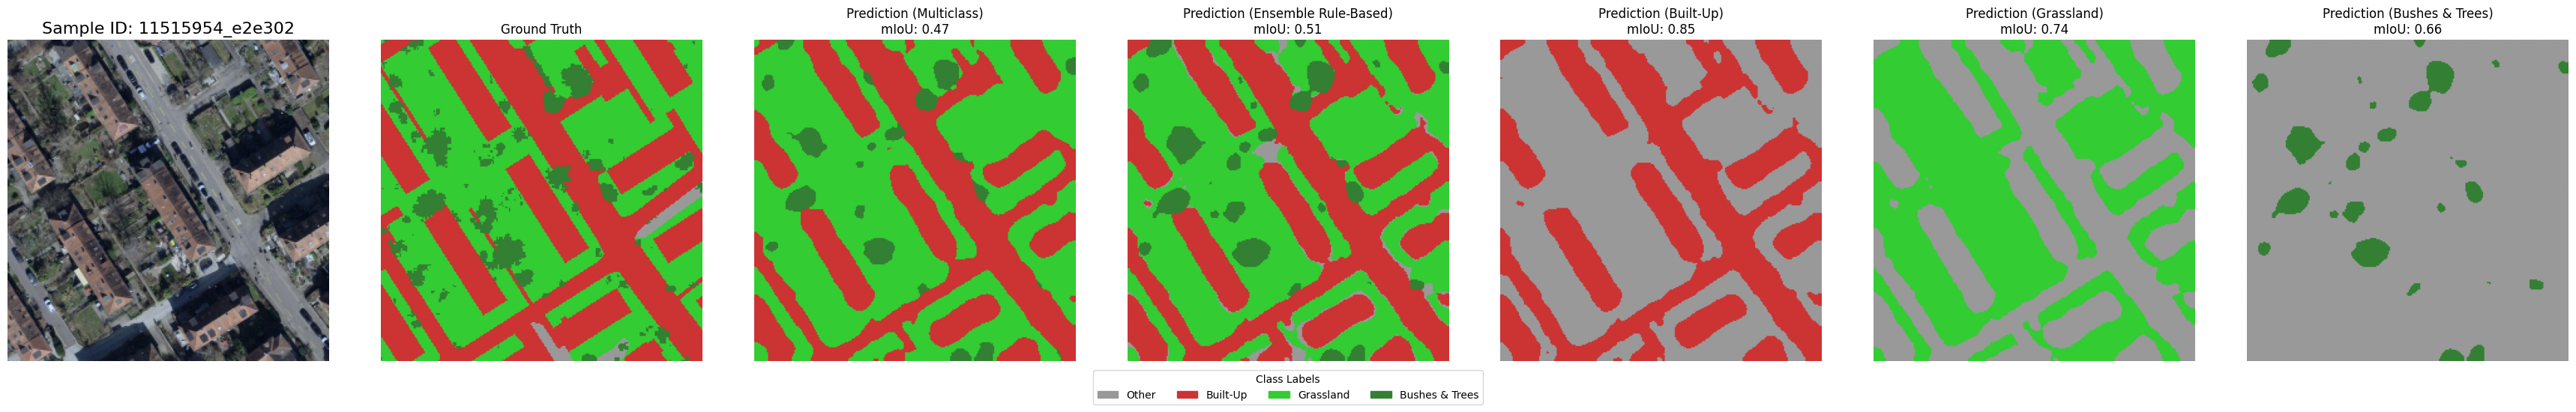

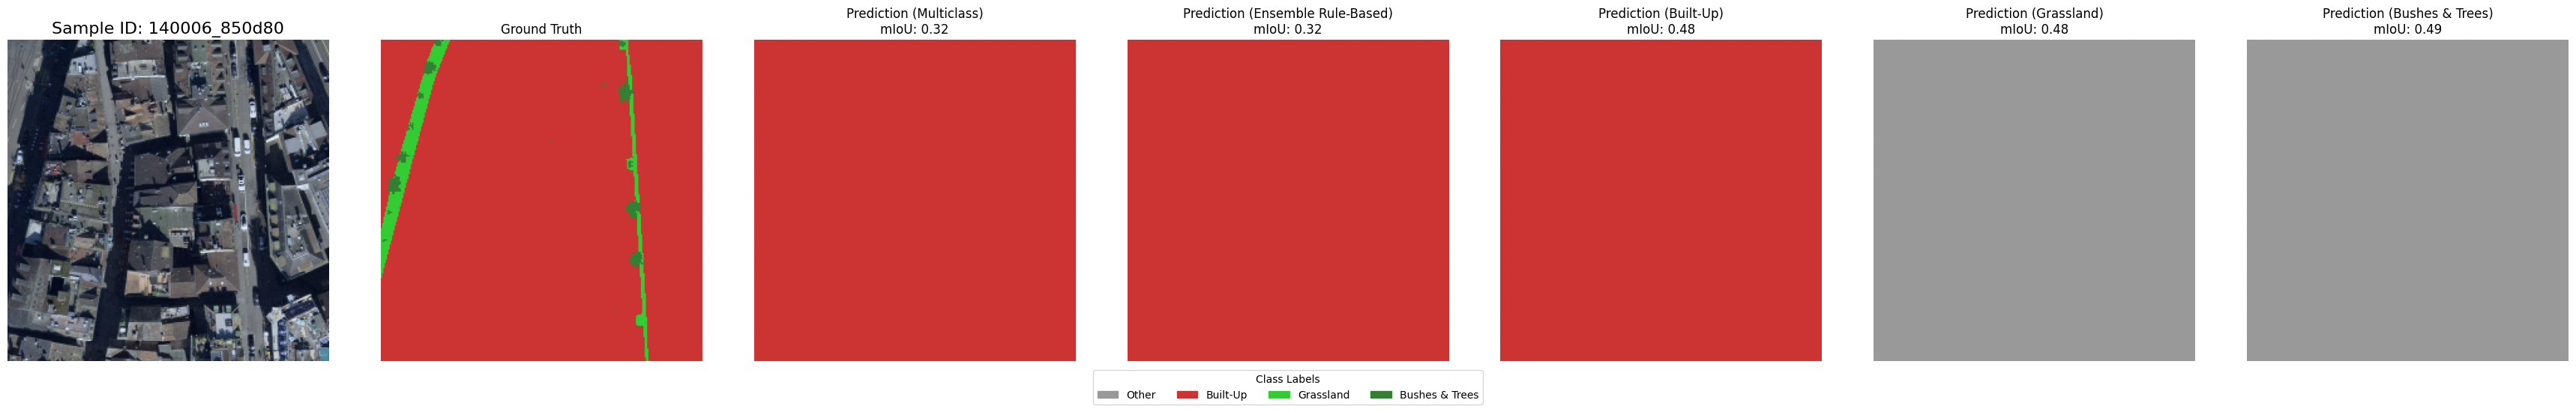

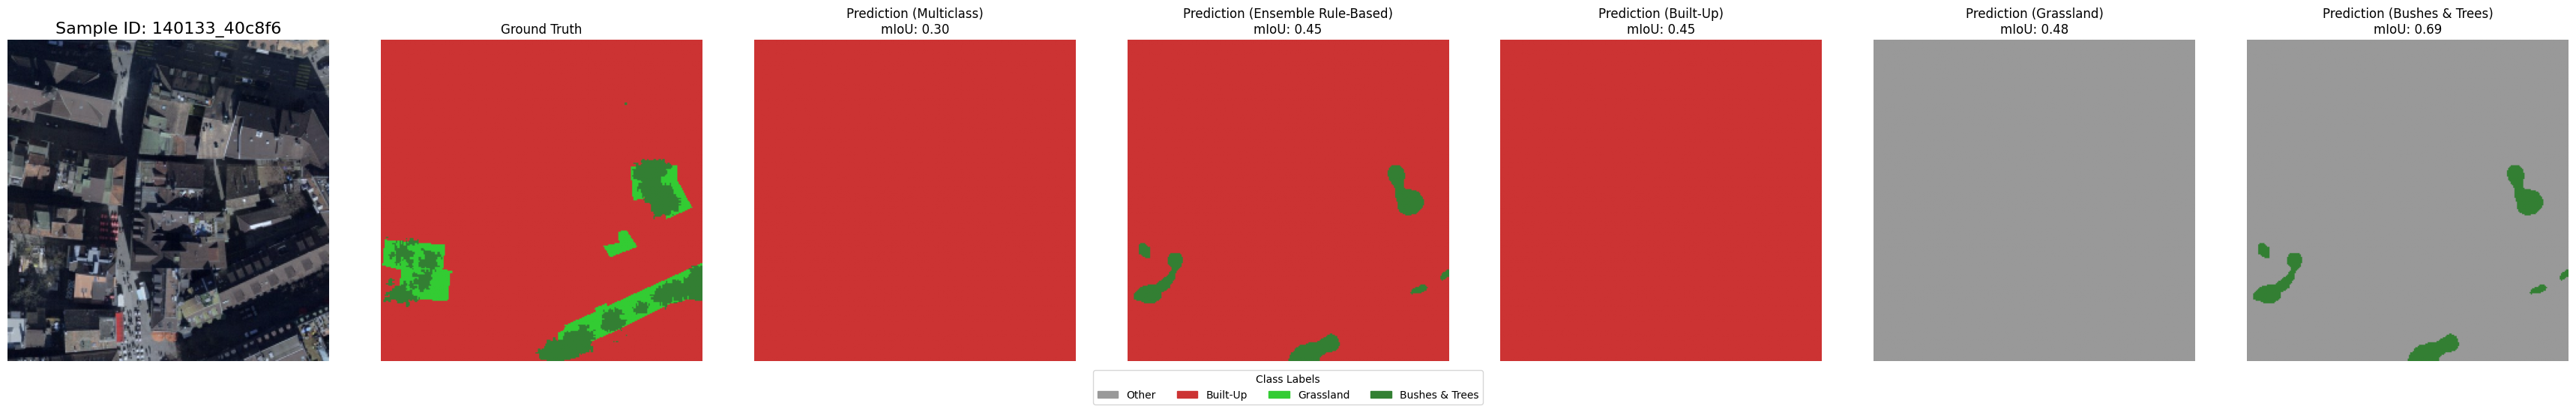

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Reuse the defined color map and id2label (from previous cells)
# colors = [
#     (0.6, 0.6, 0.6),  # Other (index 0) - Grey
#     (0.8, 0.2, 0.2),  # Built-Up (index 1) - Reddish
#     (0.2, 0.8, 0.2),  # Grassland (index 2) - Greenish
#     (0.2, 0.5, 0.2)   # Bushes & Trees (index 3) - Darker Green
# ]
# cmap = ListedColormap(colors[:num_classes])

# Create legend patches using the global id2label
patches_focused = []
for class_id, class_name in id2label.items():
    if class_id < len(colors):
        patch = mpatches.Patch(color=colors[class_id], label=class_name)
        patches_focused.append(patch)

print("\n--- Visualizing selected inference samples (Multi-Class vs. Ensemble) ---")

# Determine how many samples to visualize
num_samples_to_visualize_focused = 3 # Renamed to avoid clash with global 'num_samples_to_visualize'

# Define the desired order of models for plotting
ordered_model_names = ["Multiclass", "Ensemble Rule-Based", "Built-Up", "Grassland", "Bushes & Trees"]

if not all_model_predictions:
    print("No model predictions available for visualization.")
else:
    # Use the first model in the dictionary to get the sample images and ground truths
    # This assumes that the samples stored for visualization are consistent across models
    first_model_name = list(all_model_predictions.keys())[0]
    reference_predictions_base = all_model_predictions[first_model_name]

    # Select the first 'num_samples_to_visualize_focused' samples
    filtered_reference_predictions = reference_predictions_base[:num_samples_to_visualize_focused]

    # Filter ordered_model_names to only include models that actually exist in all_model_predictions
    existing_ordered_models = [
        m for m in ordered_model_names if m in all_model_predictions
    ]

    # Check if we have the necessary models
    if not all(model_name in all_model_predictions for model_name in existing_ordered_models):
        print("Error: Not all specified models for ordered display are found in all_model_predictions.")
        # Optionally, you might want to raise an error or exit here.

    for sample_data_ref in filtered_reference_predictions:
        img = sample_data_ref["image"]
        gt_mask = sample_data_ref["ground_truth"]
        sample_id = sample_data_ref["sample_id"]

        # Normalize image for display
        img_display = np.transpose(img, (1, 2, 0))
        img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min()) # Scale to 0-1

        fig, axes = plt.subplots(1, 2 + len(existing_ordered_models), figsize=(5 * (2 + len(existing_ordered_models)), 5))
        #fig.suptitle(f"Sample ID: {sample_id}", fontsize=16) # This title moves to image subplot

        # Plot Original Image
        axes[0].imshow(img_display)
        axes[0].set_title(f"Sample ID: {sample_id}", fontsize=16)
        axes[0].axis("off")

        # Plot Ground Truth (multi-class)
        axes[1].imshow(gt_mask, cmap=cmap, vmin=0, vmax=num_classes-1)
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        # Plot Predictions from each ordered model
        for i, model_name in enumerate(existing_ordered_models):
            # Find the correct sample data for the current model and sample_id
            # This requires finding the item in all_model_predictions[model_name] that matches sample_id
            current_model_sample_data = next((item for item in all_model_predictions[model_name] if item["sample_id"] == sample_id), None)

            if current_model_sample_data is None:
                print(f"Warning: Could not find prediction for sample_id {sample_id} in model {model_name}. Skipping.")
                continue

            raw_pred = current_model_sample_data["prediction"]
            model_type = current_model_sample_data["model_type"]

            if model_type == "binary":
                target_class_id_for_this_model = current_model_sample_data["target_class_id"]
                display_pred_mask = np.copy(raw_pred)
                display_pred_mask[raw_pred == 1] = target_class_id_for_this_model
                display_pred_mask[raw_pred == 0] = 0 # Map background to "Other" class ID
            else: # model_type == "multiclass"
                display_pred_mask = raw_pred

            # Retrieve mIoU for the current sample and model
            current_sample_row = miou_results_df[miou_results_df['sample_id'] == sample_id]
            # Column name needs to be dynamic based on model_name
            miou_col_name = f'mIoU_{model_name.replace(" ", "_")}'
            current_miou = current_sample_row[miou_col_name].iloc[0] if not current_sample_row.empty and miou_col_name in current_sample_row.columns else np.nan


            axes[2 + i].imshow(display_pred_mask, cmap=cmap, vmin=0, vmax=num_classes-1)
            axes[2 + i].set_title(f"Prediction ({model_name})\nmIoU: {current_miou:.2f}")
            axes[2 + i].axis("off")

        plt.figlegend(handles=patches_focused, loc='lower center', ncol=len(id2label), bbox_to_anchor=(0.5, -0.05), title="Class Labels")
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()

### mIoU Distribution Analysis: Histograms and Box Plots


--- Visualizing mIoU Distributions (Histograms) ---


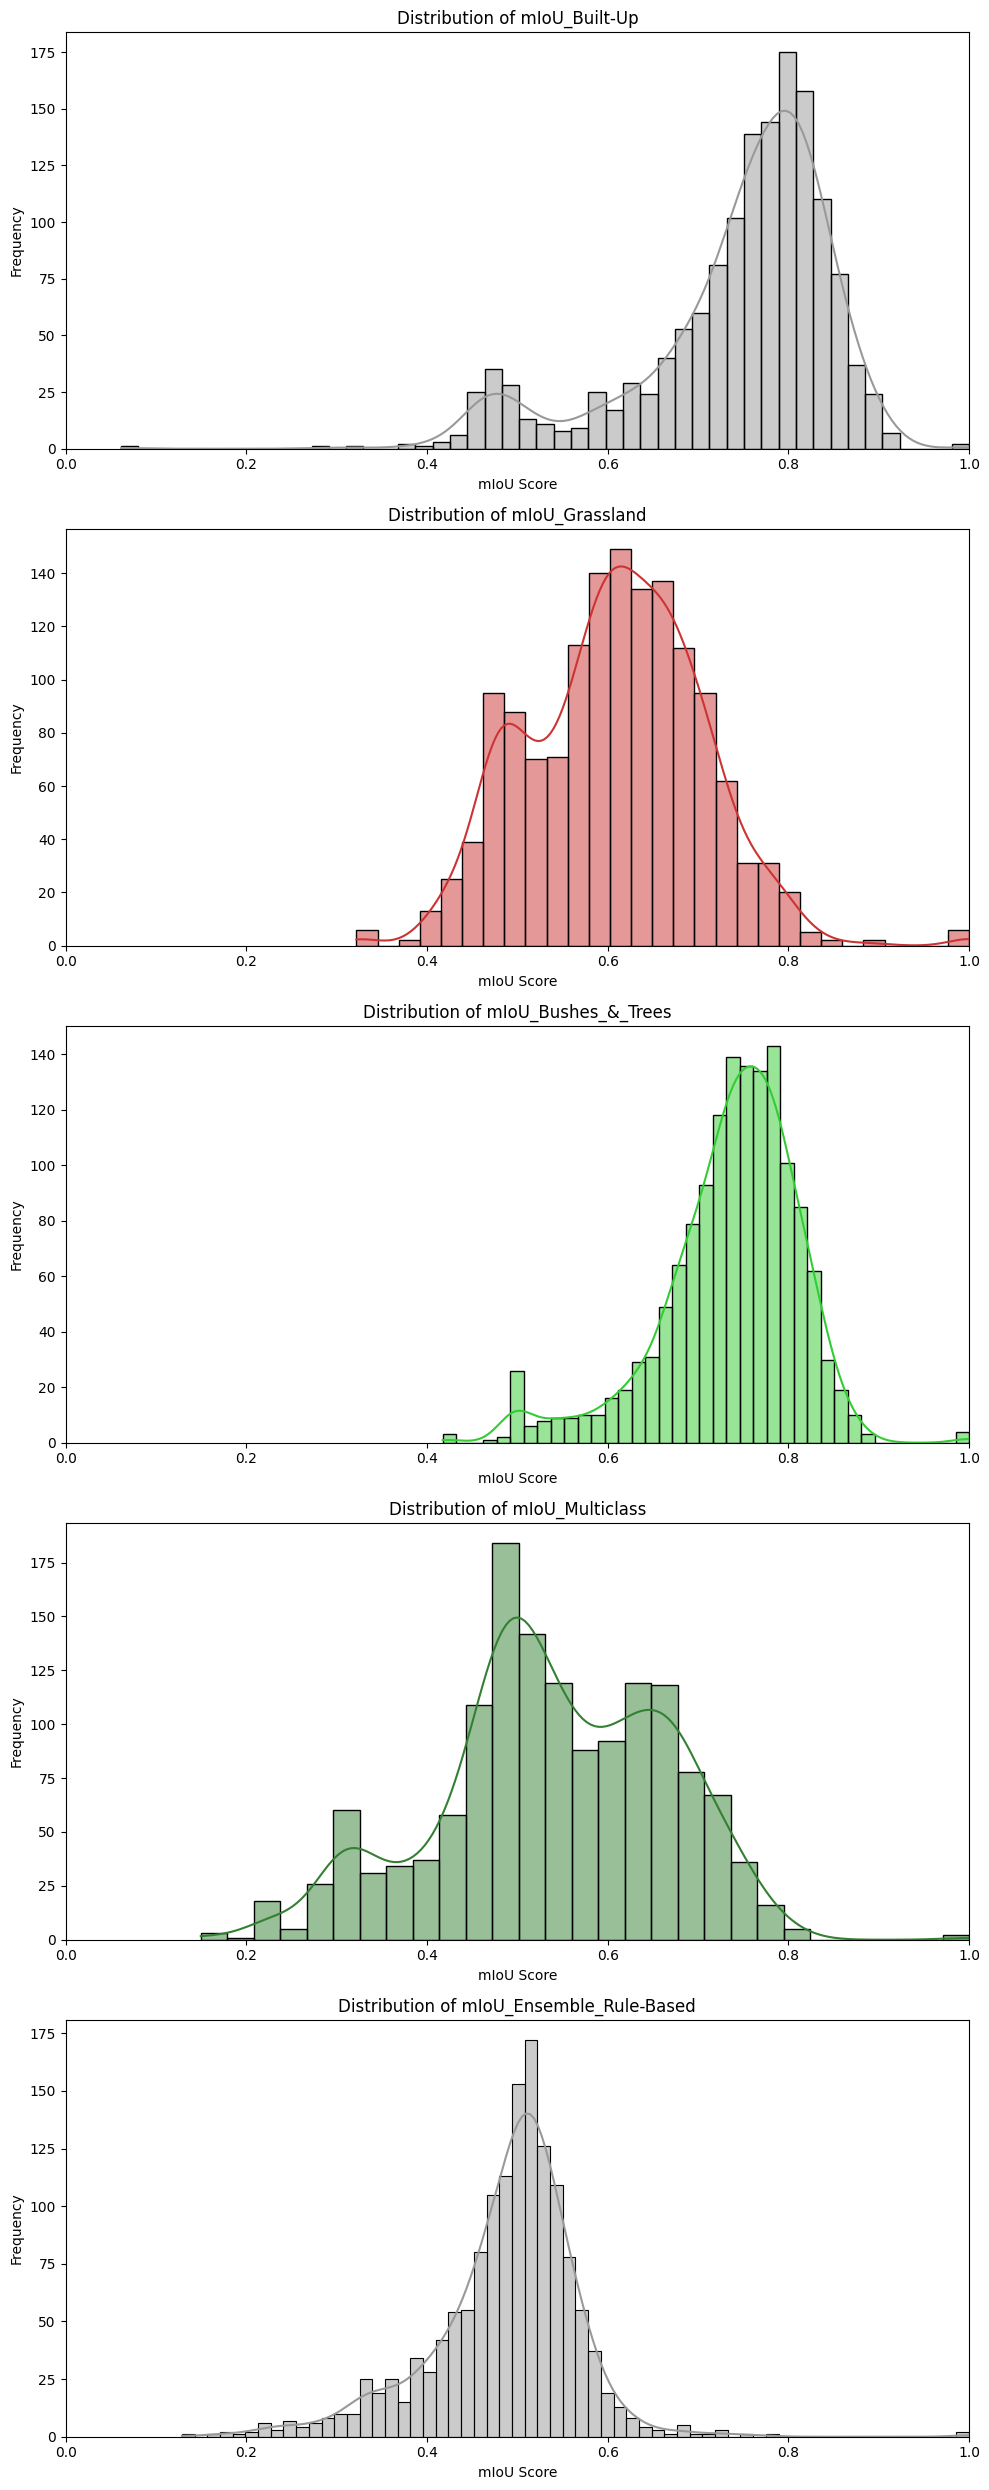


--- Visualizing mIoU Distributions (Box Plots) ---


/tmp/ipykernel_972/1205804943.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model_Readable', y='mIoU_Score', data=miou_long_df, palette='viridis', ax=ax_box)


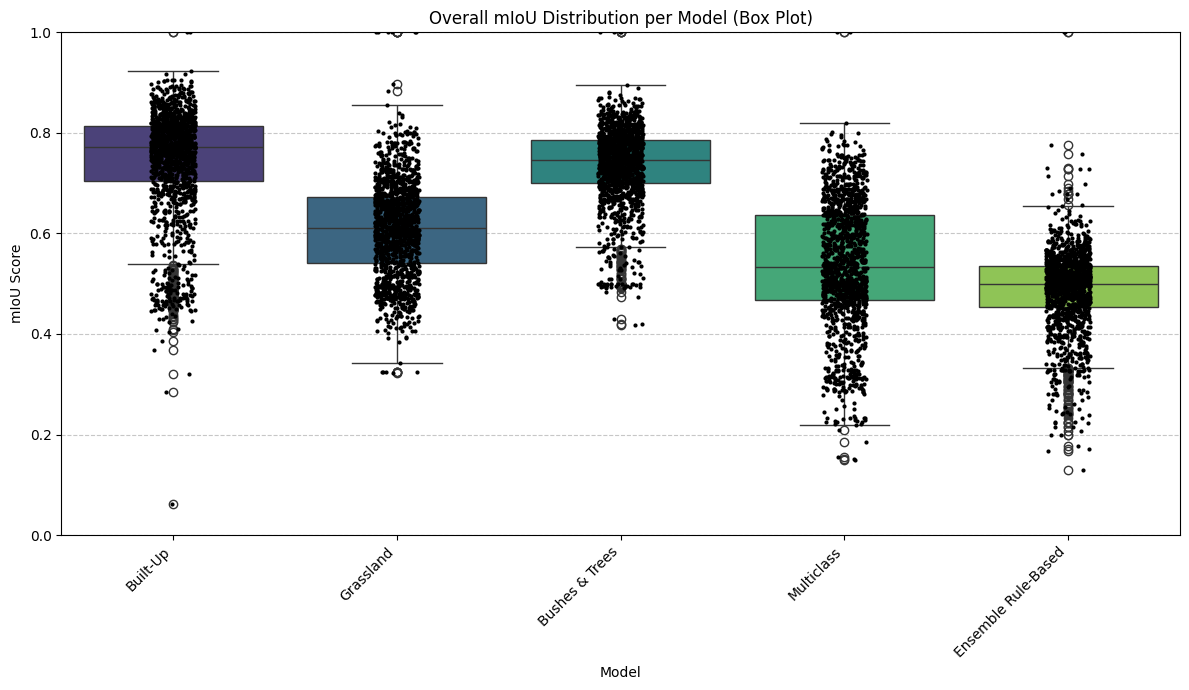

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all mIoU columns
miou_columns = [col for col in miou_results_df.columns if col.startswith('mIoU_')]

print("\n--- Visualizing mIoU Distributions (Histograms) ---")

# Plotting Histograms for each model's mIoU distribution
num_miou_cols = len(miou_columns)
fig_hist, axes_hist = plt.subplots(num_miou_cols, 1, figsize=(10, 5 * num_miou_cols))

if num_miou_cols == 1:
    axes_hist = [axes_hist] # Ensure axes_hist is iterable even for a single plot

for i, col in enumerate(miou_columns):
    sns.histplot(miou_results_df[col].dropna(), kde=True, ax=axes_hist[i], color=colors[i % len(colors)])
    axes_hist[i].set_title(f'Distribution of {col}')
    axes_hist[i].set_xlabel('mIoU Score')
    axes_hist[i].set_ylabel('Frequency')
    axes_hist[i].set_xlim(0, 1) # mIoU scores are typically between 0 and 1

plt.tight_layout()
plt.show()

print("\n--- Visualizing mIoU Distributions (Box Plots) ---")

# Prepare data for box plot (melt the DataFrame)
miou_long_df = miou_results_df[miou_columns].melt(var_name='Model', value_name='mIoU_Score')

# Create a mapping for model names to be more readable in the plot
model_name_mapping = {col: col.replace('mIoU_', '').replace('_', ' ') for col in miou_columns}
miou_long_df['Model_Readable'] = miou_long_df['Model'].map(model_name_mapping)

fig_box, ax_box = plt.subplots(figsize=(12, 7))
sns.boxplot(x='Model_Readable', y='mIoU_Score', data=miou_long_df, palette='viridis', ax=ax_box)
sns.stripplot(x='Model_Readable', y='mIoU_Score', data=miou_long_df, color='black', size=3, jitter=True, ax=ax_box)
ax_box.set_title('Overall mIoU Distribution per Model (Box Plot)')
ax_box.set_xlabel('Model')
ax_box.set_ylabel('mIoU Score')
ax_box.set_ylim(0, 1) # mIoU scores are typically between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [36]:
# Update all_model_predictions for visualization to include the ensemble
all_model_predictions[ensemble_model_name] = ensemble_predictions_for_visualization

print("Ensemble predictions added for visualization.")

Ensemble predictions added for visualization.
